# Hafta 10 - Cats vs Dogs: KNN Siniflandirma

Bu notebook, `hafta10/archive/cats_set` ve `hafta10/archive/dogs_set` klasorlerindeki goruntuleri kullanarak KNN ile ikili siniflandirma yapar.

Amaclar:
- veri setini tanimak,
- ornek goruntulerle gozlem yapmak,
- goruntuleri vektore cevirip PCA ile boyut azaltmak,
- farkli `k` degerlerini karsilastirarak en iyi KNN modelini secmek,
- karisiklik matrisi ve yanlis siniflanan ornekleri incelemek.

Kurulum notu:
Bu proje uv ile yonetilen `.venv` ortaminda calisiyor. Gerekli paketler yoksa su komutlar kullanilir:
```bash
uv venv
uv pip install numpy matplotlib seaborn pillow scikit-learn
```

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_DIR = Path("hafta10/archive")
CAT_DIR = DATA_DIR / "cats_set"
DOG_DIR = DATA_DIR / "dogs_set"
IMAGE_SIZE = (64, 64)

cat_files = sorted(CAT_DIR.glob("*.jpg"))
dog_files = sorted(DOG_DIR.glob("*.jpg"))

print(f"Cat images: {len(cat_files)}")
print(f"Dog images: {len(dog_files)}")
print(f"Total images: {len(cat_files) + len(dog_files)}")

Cat images: 500
Dog images: 500
Total images: 1000


Dataset shape: (1000, 64, 64, 3)
Pixel range: 0.0 1.0


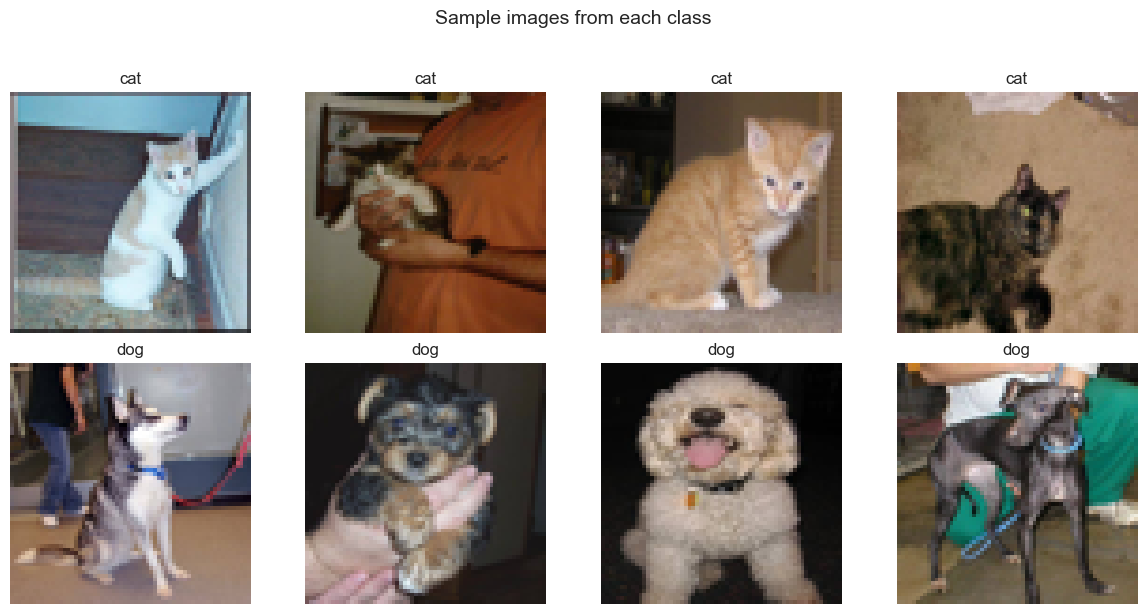

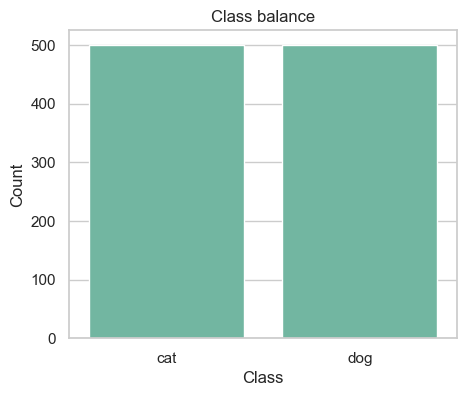

In [2]:
def load_image_array(image_path, size=IMAGE_SIZE):
    """Resmi RGB olarak okur, sabit boyuta getirir ve 0-1 araligina olceklir."""
    image = Image.open(image_path).convert("RGB").resize(size)
    return np.asarray(image, dtype=np.float32) / 255.0

def build_dataset(file_list, label_name):
    images = [load_image_array(path) for path in file_list]
    labels = [label_name] * len(file_list)
    return images, labels

cat_images, cat_labels = build_dataset(cat_files, "cat")
dog_images, dog_labels = build_dataset(dog_files, "dog")

images = np.array(cat_images + dog_images)
labels = np.array(cat_labels + dog_labels)

print("Dataset shape:", images.shape)
print("Pixel range:", images.min(), images.max())

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
sample_indices = [0, 1, 2, 3, len(cat_images), len(cat_images) + 1, len(cat_images) + 2, len(cat_images) + 3]
for ax, idx in zip(axes.ravel(), sample_indices):
    ax.imshow(images[idx])
    ax.set_title(labels[idx])
    ax.axis("off")
plt.suptitle("Sample images from each class", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.countplot(x=labels)
plt.title("Class balance")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Train size: 800
Test size: 200


k= 1 | CV accuracy = 0.4950 +/- 0.0232
k= 3 | CV accuracy = 0.5050 +/- 0.0183
k= 5 | CV accuracy = 0.5050 +/- 0.0266
k= 7 | CV accuracy = 0.5050 +/- 0.0382
k= 9 | CV accuracy = 0.4725 +/- 0.0300
k=11 | CV accuracy = 0.5075 +/- 0.0269
k=13 | CV accuracy = 0.4800 +/- 0.0203
k=15 | CV accuracy = 0.4987 +/- 0.0222


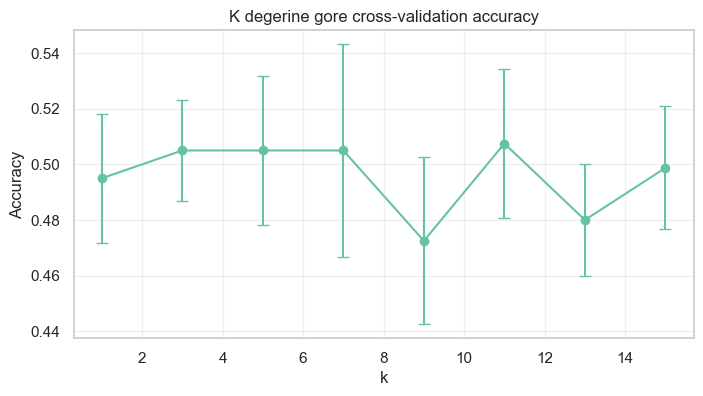

Best k: 11


In [3]:
# KNN icin goruntuleri tek boyutlu vektor haline getiriyoruz.
X = images.reshape(len(images), -1)
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

k_values = [1, 3, 5, 7, 9, 11, 13, 15]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for k in k_values:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=100, random_state=RANDOM_STATE)),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    results.append((k, scores.mean(), scores.std()))
    print(f"k={k:2d} | CV accuracy = {scores.mean():.4f} +/- {scores.std():.4f}")

results_table = np.array(results, dtype=float)
best_index = int(results_table[:, 1].argmax())
best_k = int(results[best_index][0])

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(results_table[:, 0], results_table[:, 1], yerr=results_table[:, 2], marker="o", capsize=4)
ax.set_title("K degerine gore cross-validation accuracy")
ax.set_xlabel("k")
ax.set_ylabel("Accuracy")
ax.grid(True, alpha=0.3)
plt.show()

print(f"Best k: {best_k}")

Test accuracy: 0.5450

Classification report:
              precision    recall  f1-score   support

         cat       0.54      0.65      0.59       100
         dog       0.56      0.44      0.49       100

    accuracy                           0.55       200
   macro avg       0.55      0.55      0.54       200
weighted avg       0.55      0.55      0.54       200



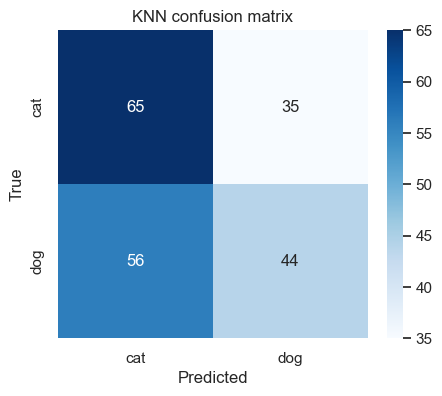

In [8]:
best_k=10
best_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=100, random_state=RANDOM_STATE)),
    ("knn", KNeighborsClassifier(n_neighbors=best_k)),
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {test_accuracy:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=["cat", "dog"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["cat", "dog"], yticklabels=["cat", "dog"], ax=ax)
ax.set_title("KNN confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.show()

Misclassified examples: 91 / 200


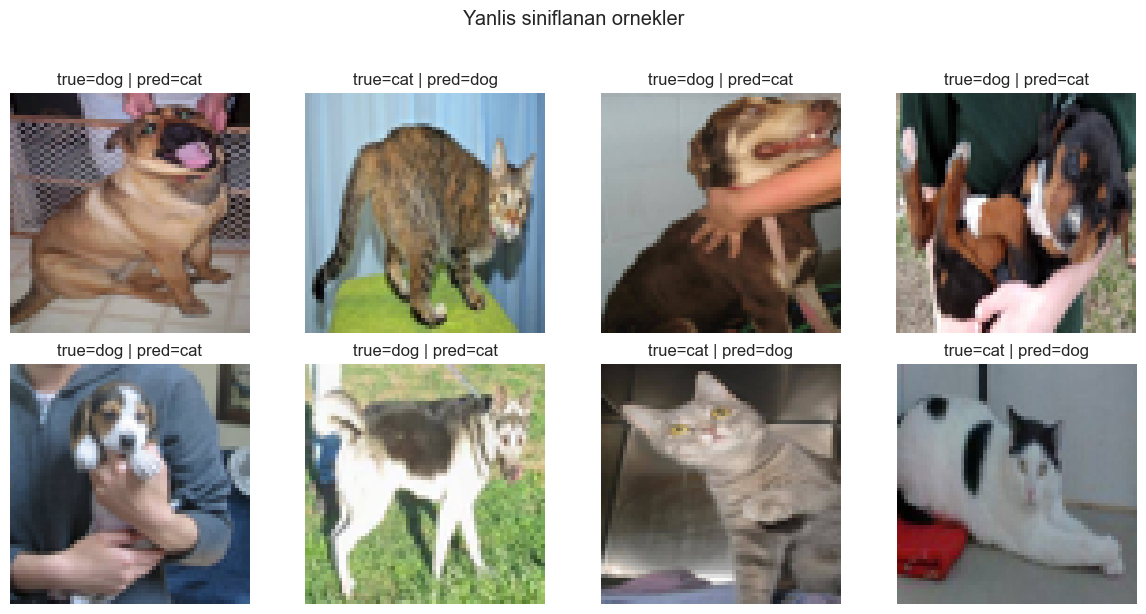

Example image: dog.4001.jpg
Predicted label: cat
Probabilities: cat=0.500, dog=0.500


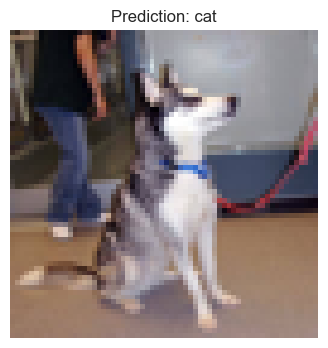

In [10]:
misclassified_indices = np.where(y_pred != y_test)[0]
print(f"Misclassified examples: {len(misclassified_indices)} / {len(y_test)}")

if len(misclassified_indices) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, idx in zip(axes.ravel(), misclassified_indices[:8]):
        image = X_test[idx].reshape(*IMAGE_SIZE, 3)
        ax.imshow(image)
        ax.set_title(f"true={y_test[idx]} | pred={y_pred[idx]}")
        ax.axis("off")
    plt.suptitle("Yanlis siniflanan ornekler", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Yanlis siniflanan ornek bulunamadi.")

def predict_image(image_path):
    image = load_image_array(image_path).reshape(1, -1)
    probabilities = best_pipeline.predict_proba(image)[0]
    predicted_label = best_pipeline.predict(image)[0]
    return predicted_label, probabilities

example_image = dog_files[0]
predicted_label, probabilities = predict_image(example_image)
print(f"Example image: {example_image.name}")
print(f"Predicted label: {predicted_label}")
print(f"Probabilities: cat={probabilities[0]:.3f}, dog={probabilities[1]:.3f}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(load_image_array(example_image))
ax.set_title(f"Prediction: {predicted_label}")
ax.axis("off")
plt.show()